In [111]:
! pip install Pillow


[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from scipy import signal
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter
import math
from PIL import Image, ImageDraw

## 1.グリッドの定義と描画

### 入力
- フロアマップの幅[px] : 2,837px ` map_width_px (int)`
- フロアマップの高さ[px]:  3,742px `map_height_px (int)`
- グリッドの一辺の長さ[px] : 30px `grid_size_px (int)`

### 出力
- 横方向のグリッド数 95 `num_grids_x`
- 縦方向のグリッド数 125 `num_grids_y`

### アルゴリズム
フロアマップの寸法とグリッドサイズから、横方向と縦方向にいくつのグリッドができるかを計算
- 横方向のグリッド数： $N_x = \lceil W / G \rceil = \lceil 2837 / 30 \rceil = \lceil 94.56... \rceil = 95$
- 縦方向のグリッド数： $N_y = \lceil H / G \rceil = \lceil 3742 / 30 \rceil = \lceil 124.73... \rceil = 125$



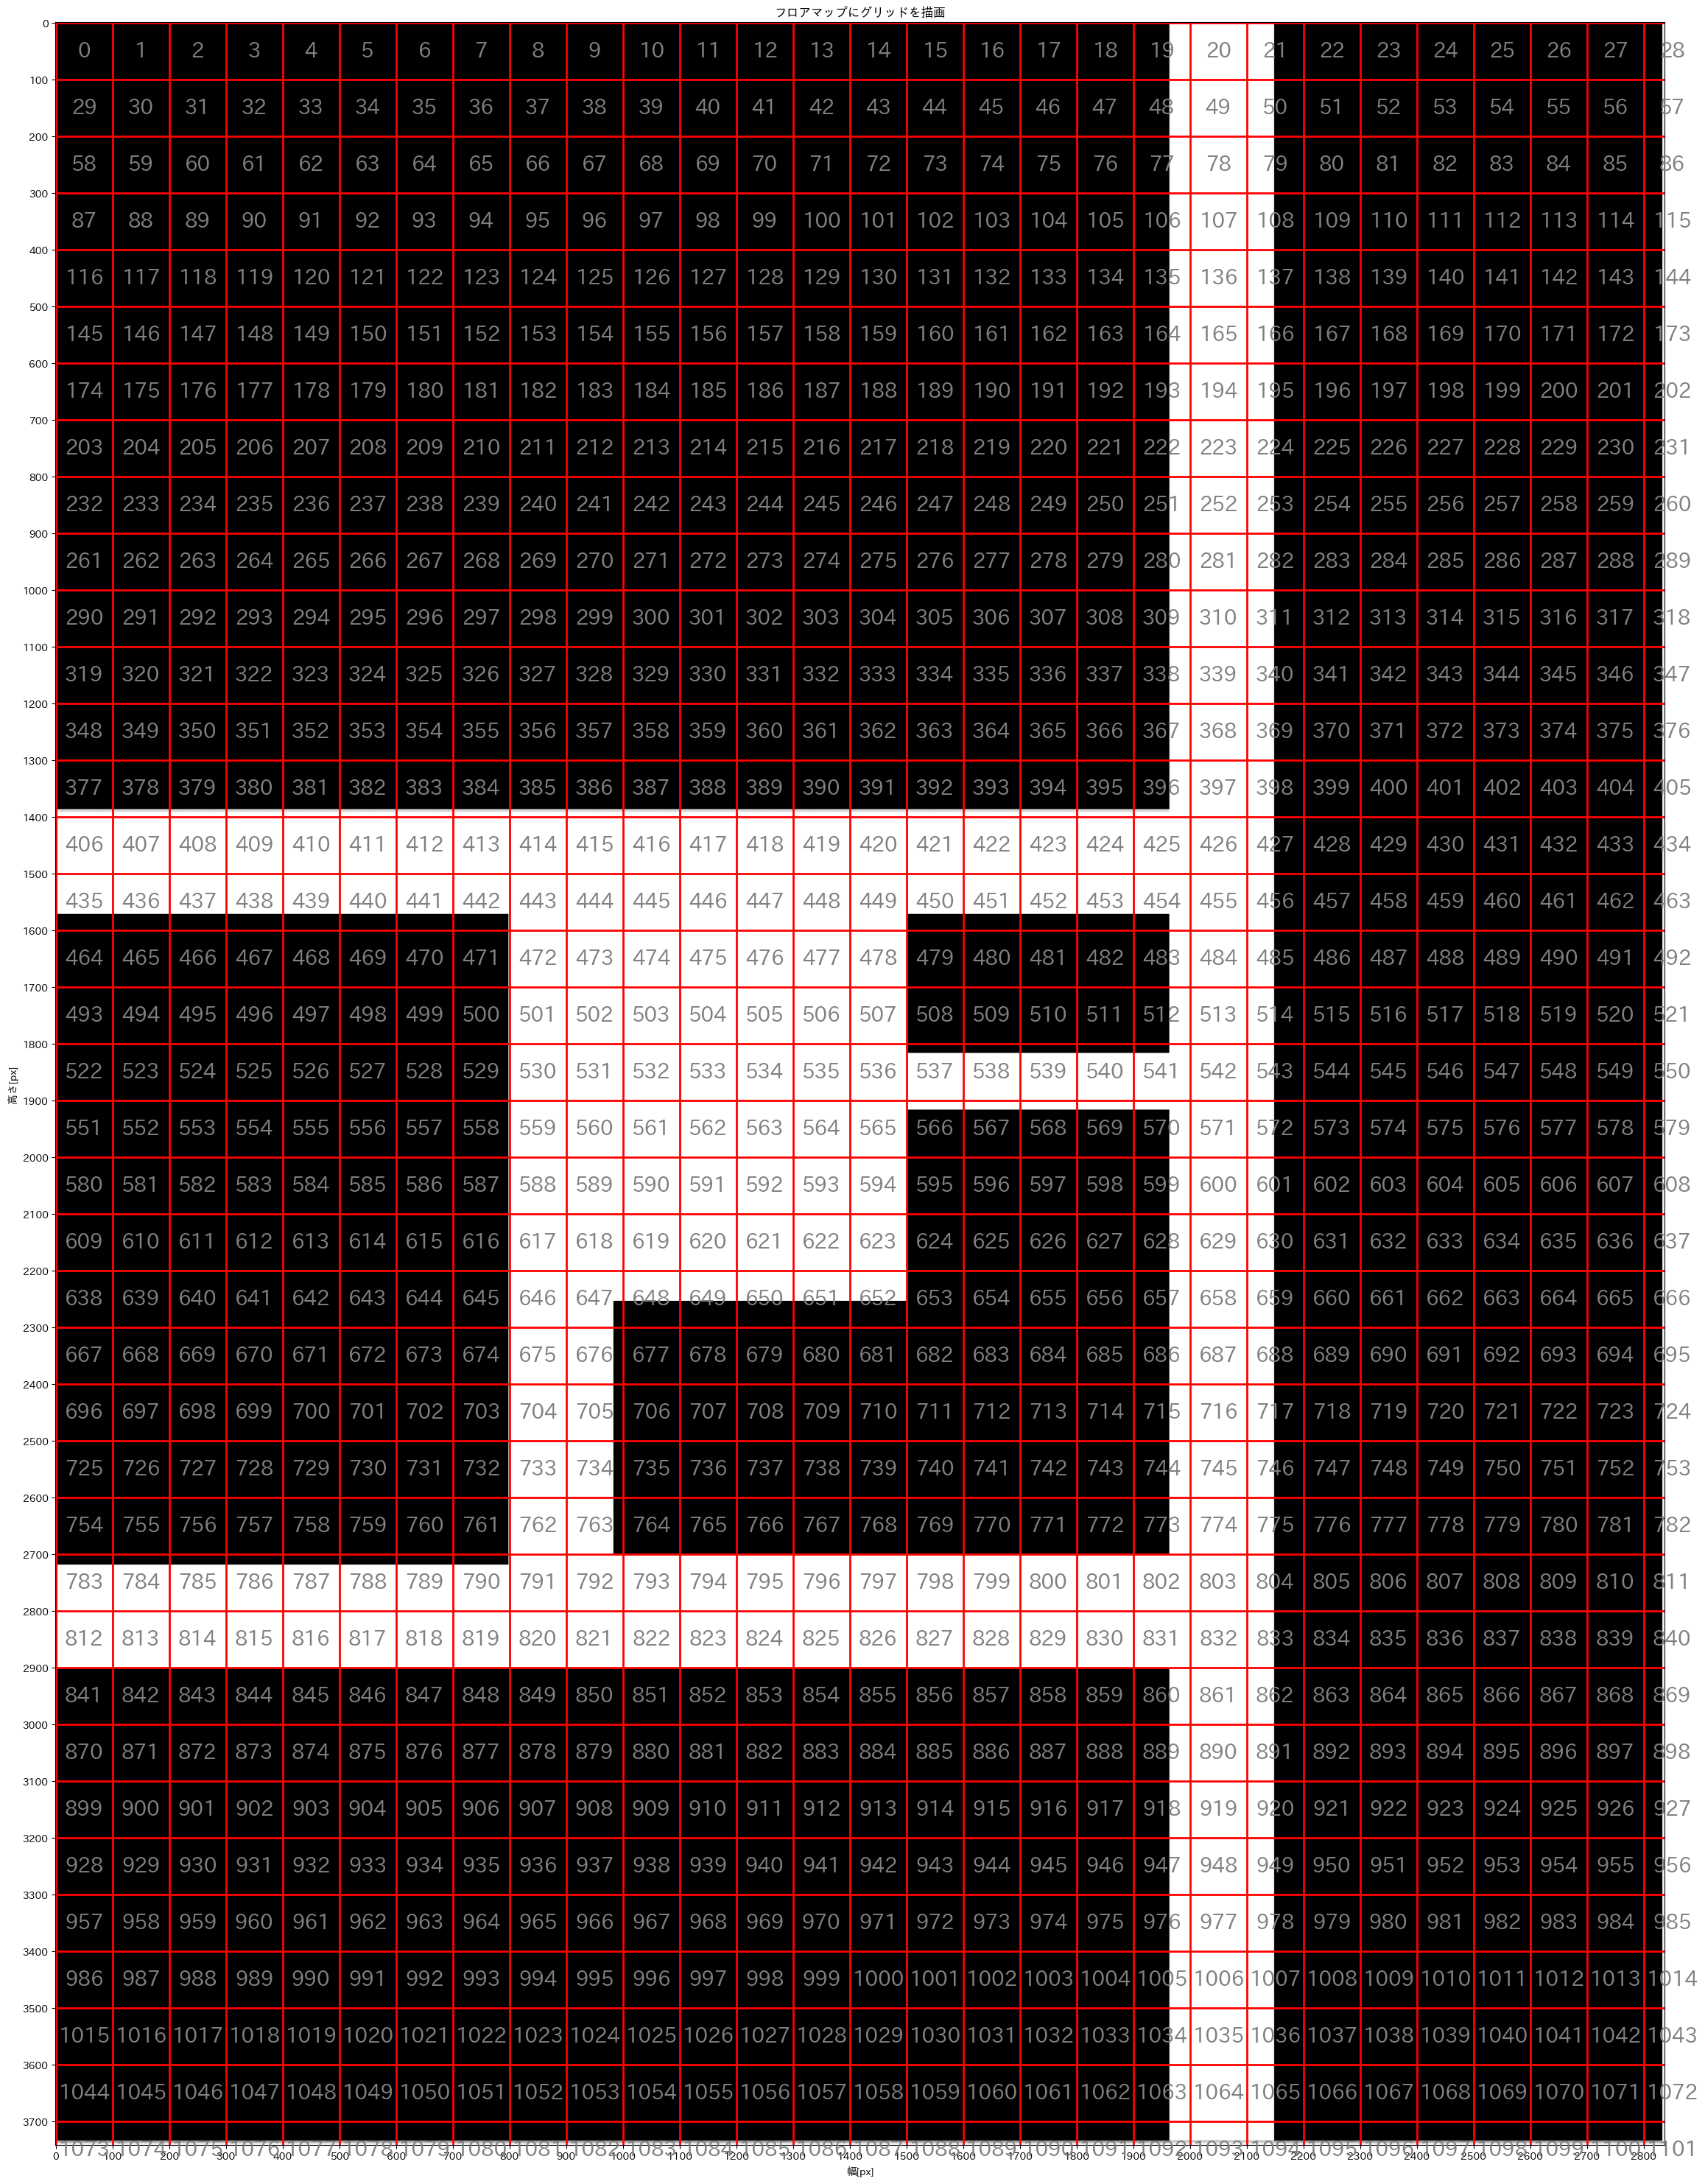

--- グリッド定義 ---
フロアマップの幅: 2837 px
フロアマップの高さ: 3742 px
グリッドサイズ: 100 px
実際のサイズ: 1m
横方向のグリッド数 (Nx): 29
縦方向のグリッド数 (Ny): 38
--------------------


In [113]:
# 1. グリッドの定義
# 提供されたフロアマップの寸法を使用
from matplotlib import ticker


map_width = 2837
map_height = 3742
# 提案されたグリッドサイズ
grid_size = 100 


num_grids_x = math.ceil(map_width / grid_size)
num_grids_y = math.ceil(map_height / grid_size)

img = Image.open("../../docs/floorMap/building＝14,floor=5_freeSpace.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img)

# グリッドの間隔を設定
# MultipleLocatorを使って、指定したgrid_sizeごとにグリッド線を表示
ax.xaxis.set_major_locator(ticker.MultipleLocator(grid_size))
ax.yaxis.set_major_locator(ticker.MultipleLocator(grid_size))


# グリッドを表示
ax.grid(which='major', color='red', linestyle='-', linewidth=2)


# 4. 各グリッドにIDを割り振って描画
grid_data = []
grid_id = 0
for y in range(num_grids_y):
    for x in range(num_grids_x):
        # グリッドの中心座標を計算
        center_x = x * grid_size + grid_size / 2
        center_y = y * grid_size + grid_size / 2

        # グリッドの中心にIDを描画
        ax.text(center_x, center_y, str(grid_id), color='gray',
                ha='center', va='center', fontsize=20)

        # グリッドの情報を辞書として保存
        grid_info = {
            'id': grid_id,
            'x_min': x * grid_size,
            'y_min': y * grid_size,
            'x_max': (x + 1) * grid_size,
            'y_max': (y + 1) * grid_size
        }
        grid_data.append(grid_info)
        grid_id += 1


# 画像を表示
plt.title('フロアマップにグリッドを描画')
plt.xlabel('幅[px]')
plt.ylabel('高さ[px]')
fig.savefig("output/gridFloorMap.png", bbox_inches='tight', dpi=100)
plt.show()



print(f"--- グリッド定義 ---")
print(f"フロアマップの幅: {map_width} px")
print(f"フロアマップの高さ: {map_height} px")
print(f"グリッドサイズ: {grid_size} px")
print(f"実際のサイズ: 1m")
print(f"横方向のグリッド数 (Nx): {num_grids_x}")
print(f"縦方向のグリッド数 (Ny): {num_grids_y}")
print("-" * 20)


# 歩行軌跡をフロアマップにマッピング

## Step.0 軌跡データの取得

<Figure size 640x480 with 0 Axes>

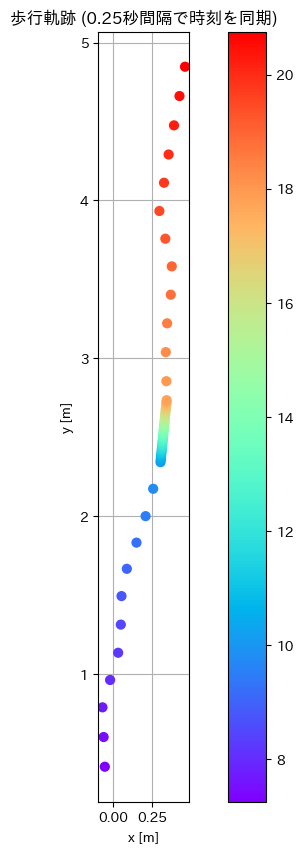

In [114]:
# データの読み込み
trajectory_file_path = "../practice/data/0527walking_trajectory.csv"
df_trajectory = pd.read_csv(trajectory_file_path)


plt.subplots_adjust(hspace=0.3)
fig = plt.figure(figsize=(10, 10))

x = df_trajectory['x']
y = df_trajectory['y'] 
time = df_trajectory['time']

# 補間された軌跡を描画
plt.colorbar(plt.scatter(x, y,c=time,cmap='rainbow',s=40, label=f'推定軌跡', zorder=2))

plt.gca().set_aspect('equal', adjustable='box')
plt.title('歩行軌跡 (0.25秒間隔で時刻を同期)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid(True)

plt.show()

## Step.1 スケール（縮尺）の補正

In [115]:
# --- パラメータ定義 ---
estimated_distance = 5.0
correct_distance = 10.0

# 変換計算
# 1. スケール補正係数と最終的なスケールを計算
scale_correction = correct_distance / estimated_distance
final_scale = 100 * scale_correction

# 4. 軌跡データに変換を適用
x_scaled = df_trajectory['x'] * final_scale
y_scaled = df_trajectory['y'] * final_scale

# 変換後の座標をDataFrameに追加
df_trajectory['x'] = x_scaled
df_trajectory['y'] = y_scaled



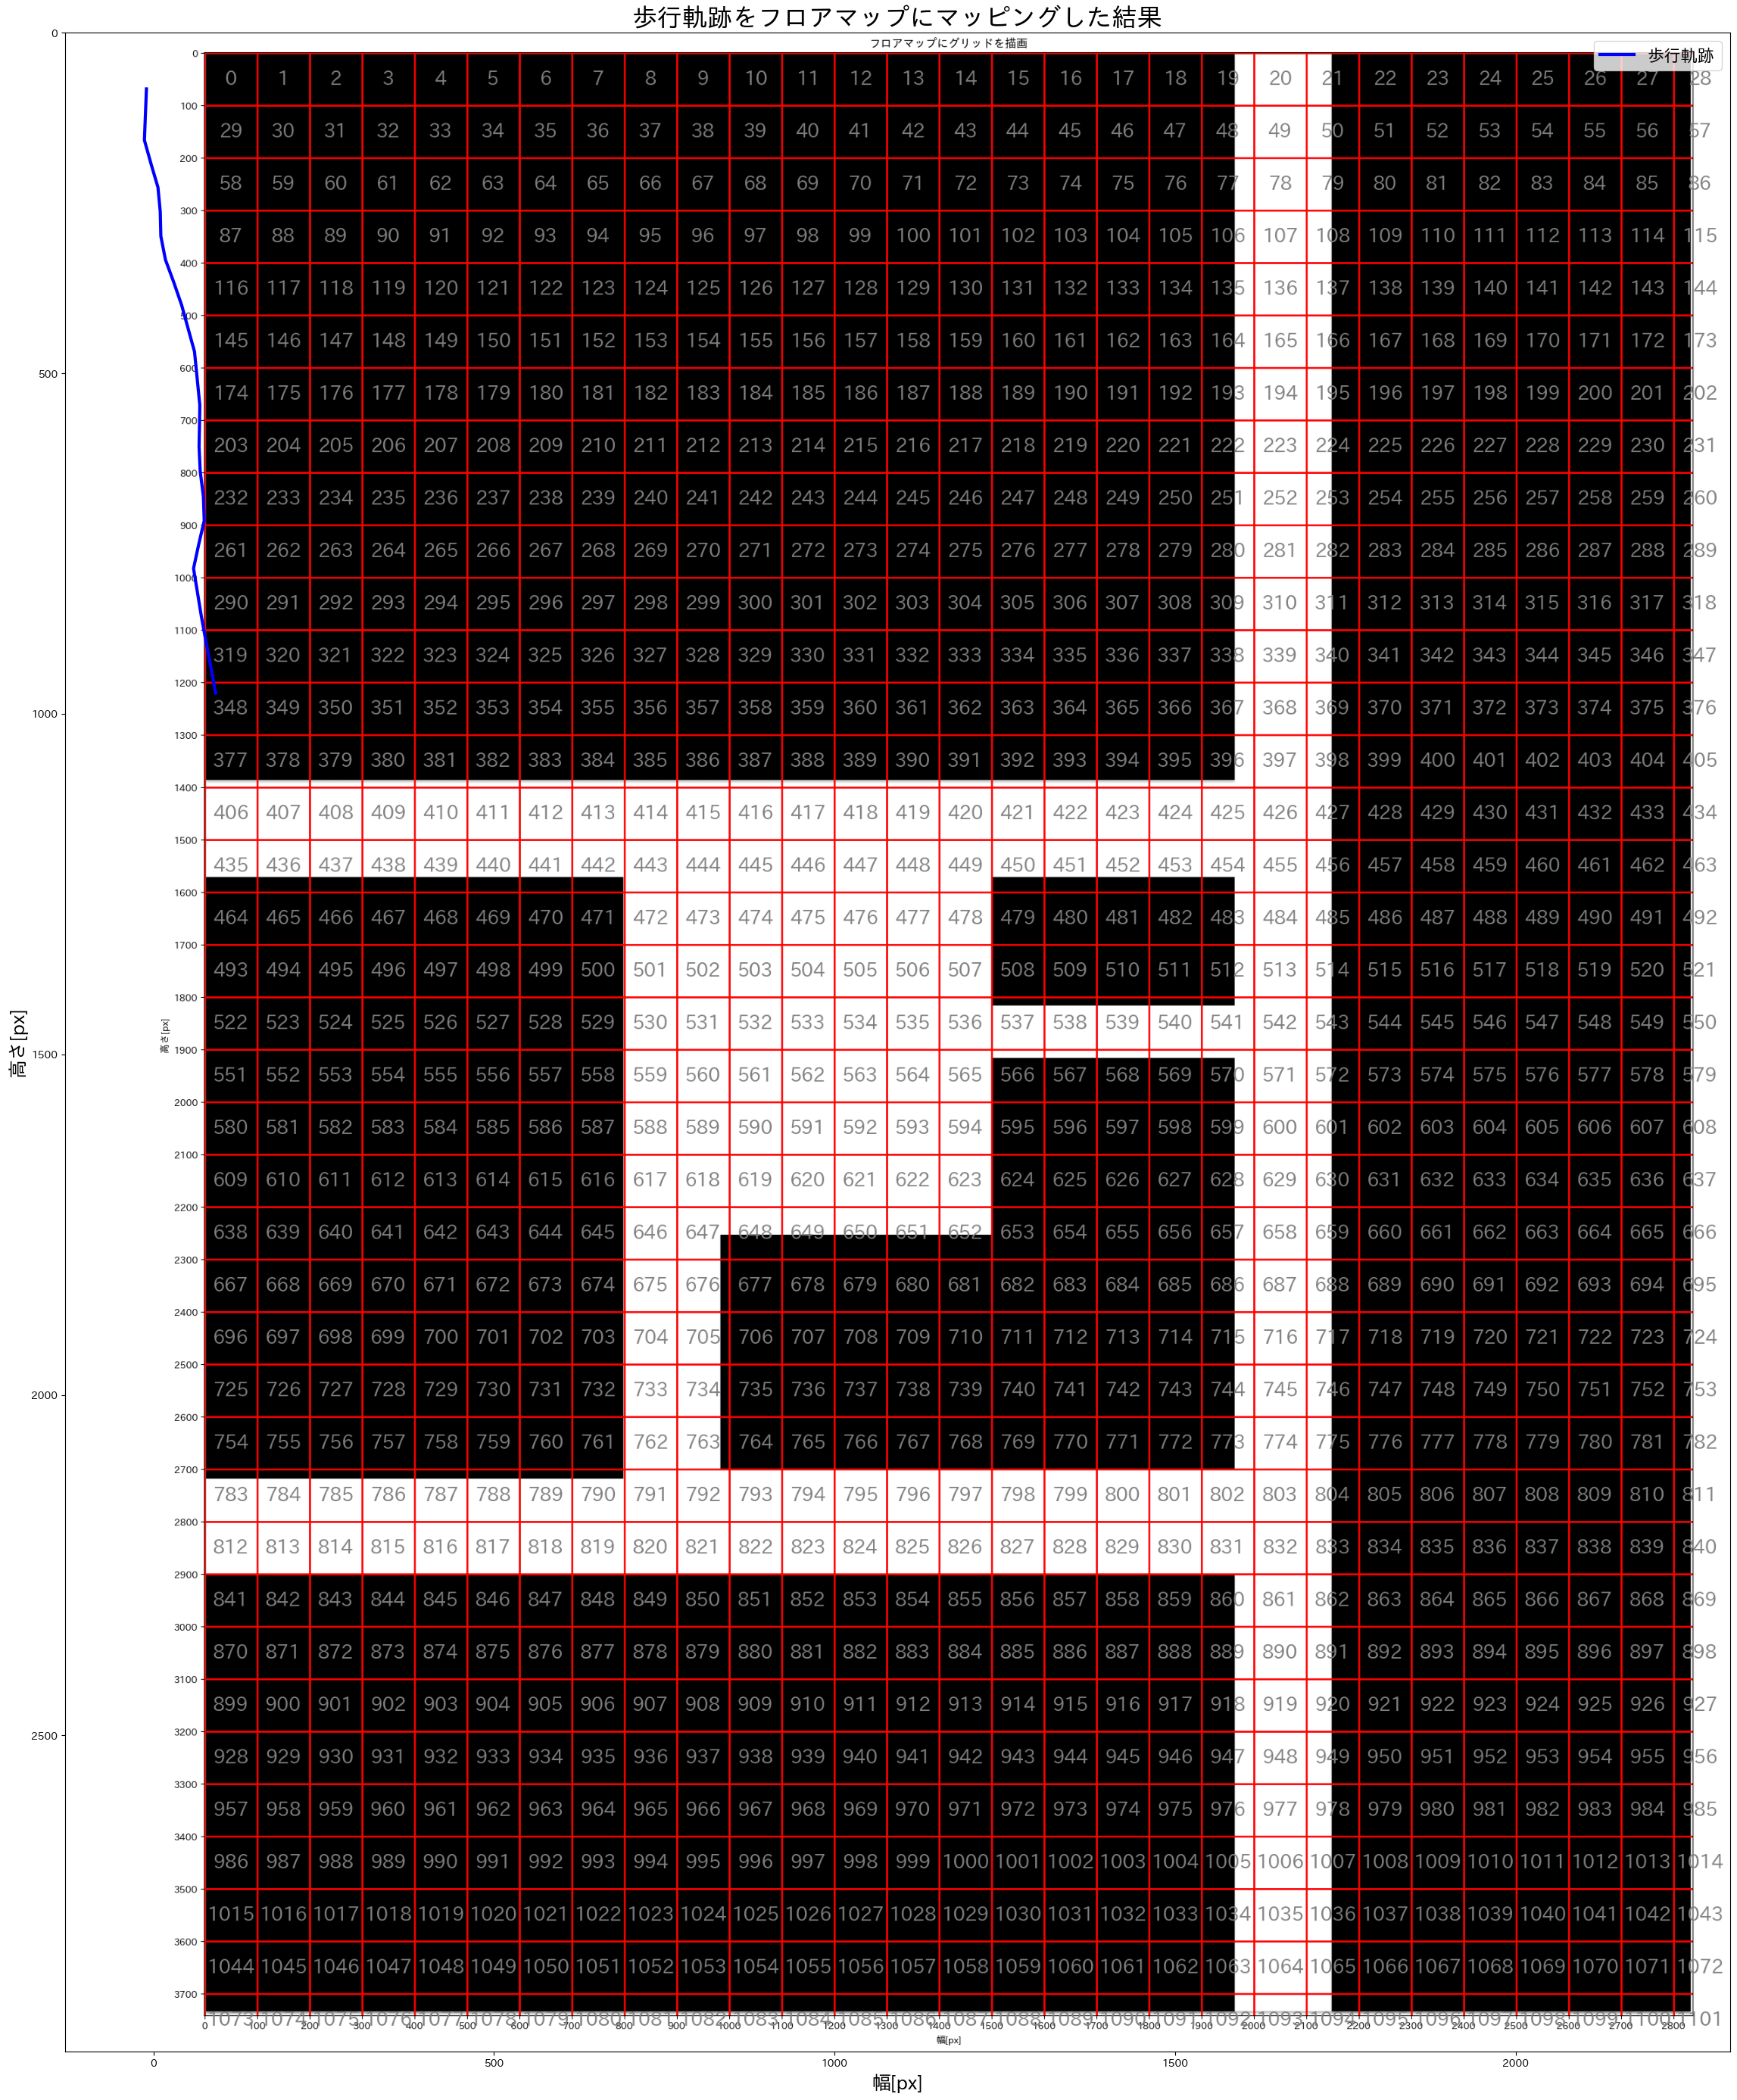

In [116]:
# グリッド付きフロアマップ画像を読み込み
img_grid = Image.open("output/gridFloorMap.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img_grid)

# 変換後の軌跡をプロット
ax.plot(df_trajectory['x'], df_trajectory['y'], 
        color='blue', linewidth=3, label='歩行軌跡')

# グラフの装飾
plt.title('歩行軌跡をフロアマップにマッピングした結果', fontsize=24)
plt.xlabel('幅[px]', fontsize=18)
plt.ylabel('高さ[px]', fontsize=18)
plt.legend(fontsize=16)
plt.show()


## Step.2 初期位置,初期方向の指定(座標変換)
初期位置の決定: 軌跡の開始点 `(0, 0)` がフロアマップ上のどこに対応するのかを決める
初期方向の決定: 軌跡がどの方向を向いているかを合わせる


In [117]:
#----パラメータ定義-------
# （例: -90度は時計回りに90度回転）
correct_angle = 180.0

 # 度数法からラジアンに変換
angle_rad = np.deg2rad(correct_angle)
cos_theta = np.cos(angle_rad)
sin_theta = np.sin(angle_rad)
    

# 計算結果を新しい変数(new_x, new_y)に格納し、元の変数を上書きしないようにします
x_rotated_px =  df_trajectory['x']* cos_theta - df_trajectory['y'] * sin_theta
y_rotated_px = df_trajectory['x']* sin_theta + df_trajectory['y'] * cos_theta

    
# 回転後の座標を持つ新しいデータフレームを作成
df_trajectory = pd.DataFrame({
    'x': x_rotated_px,
    'y': y_rotated_px
 })



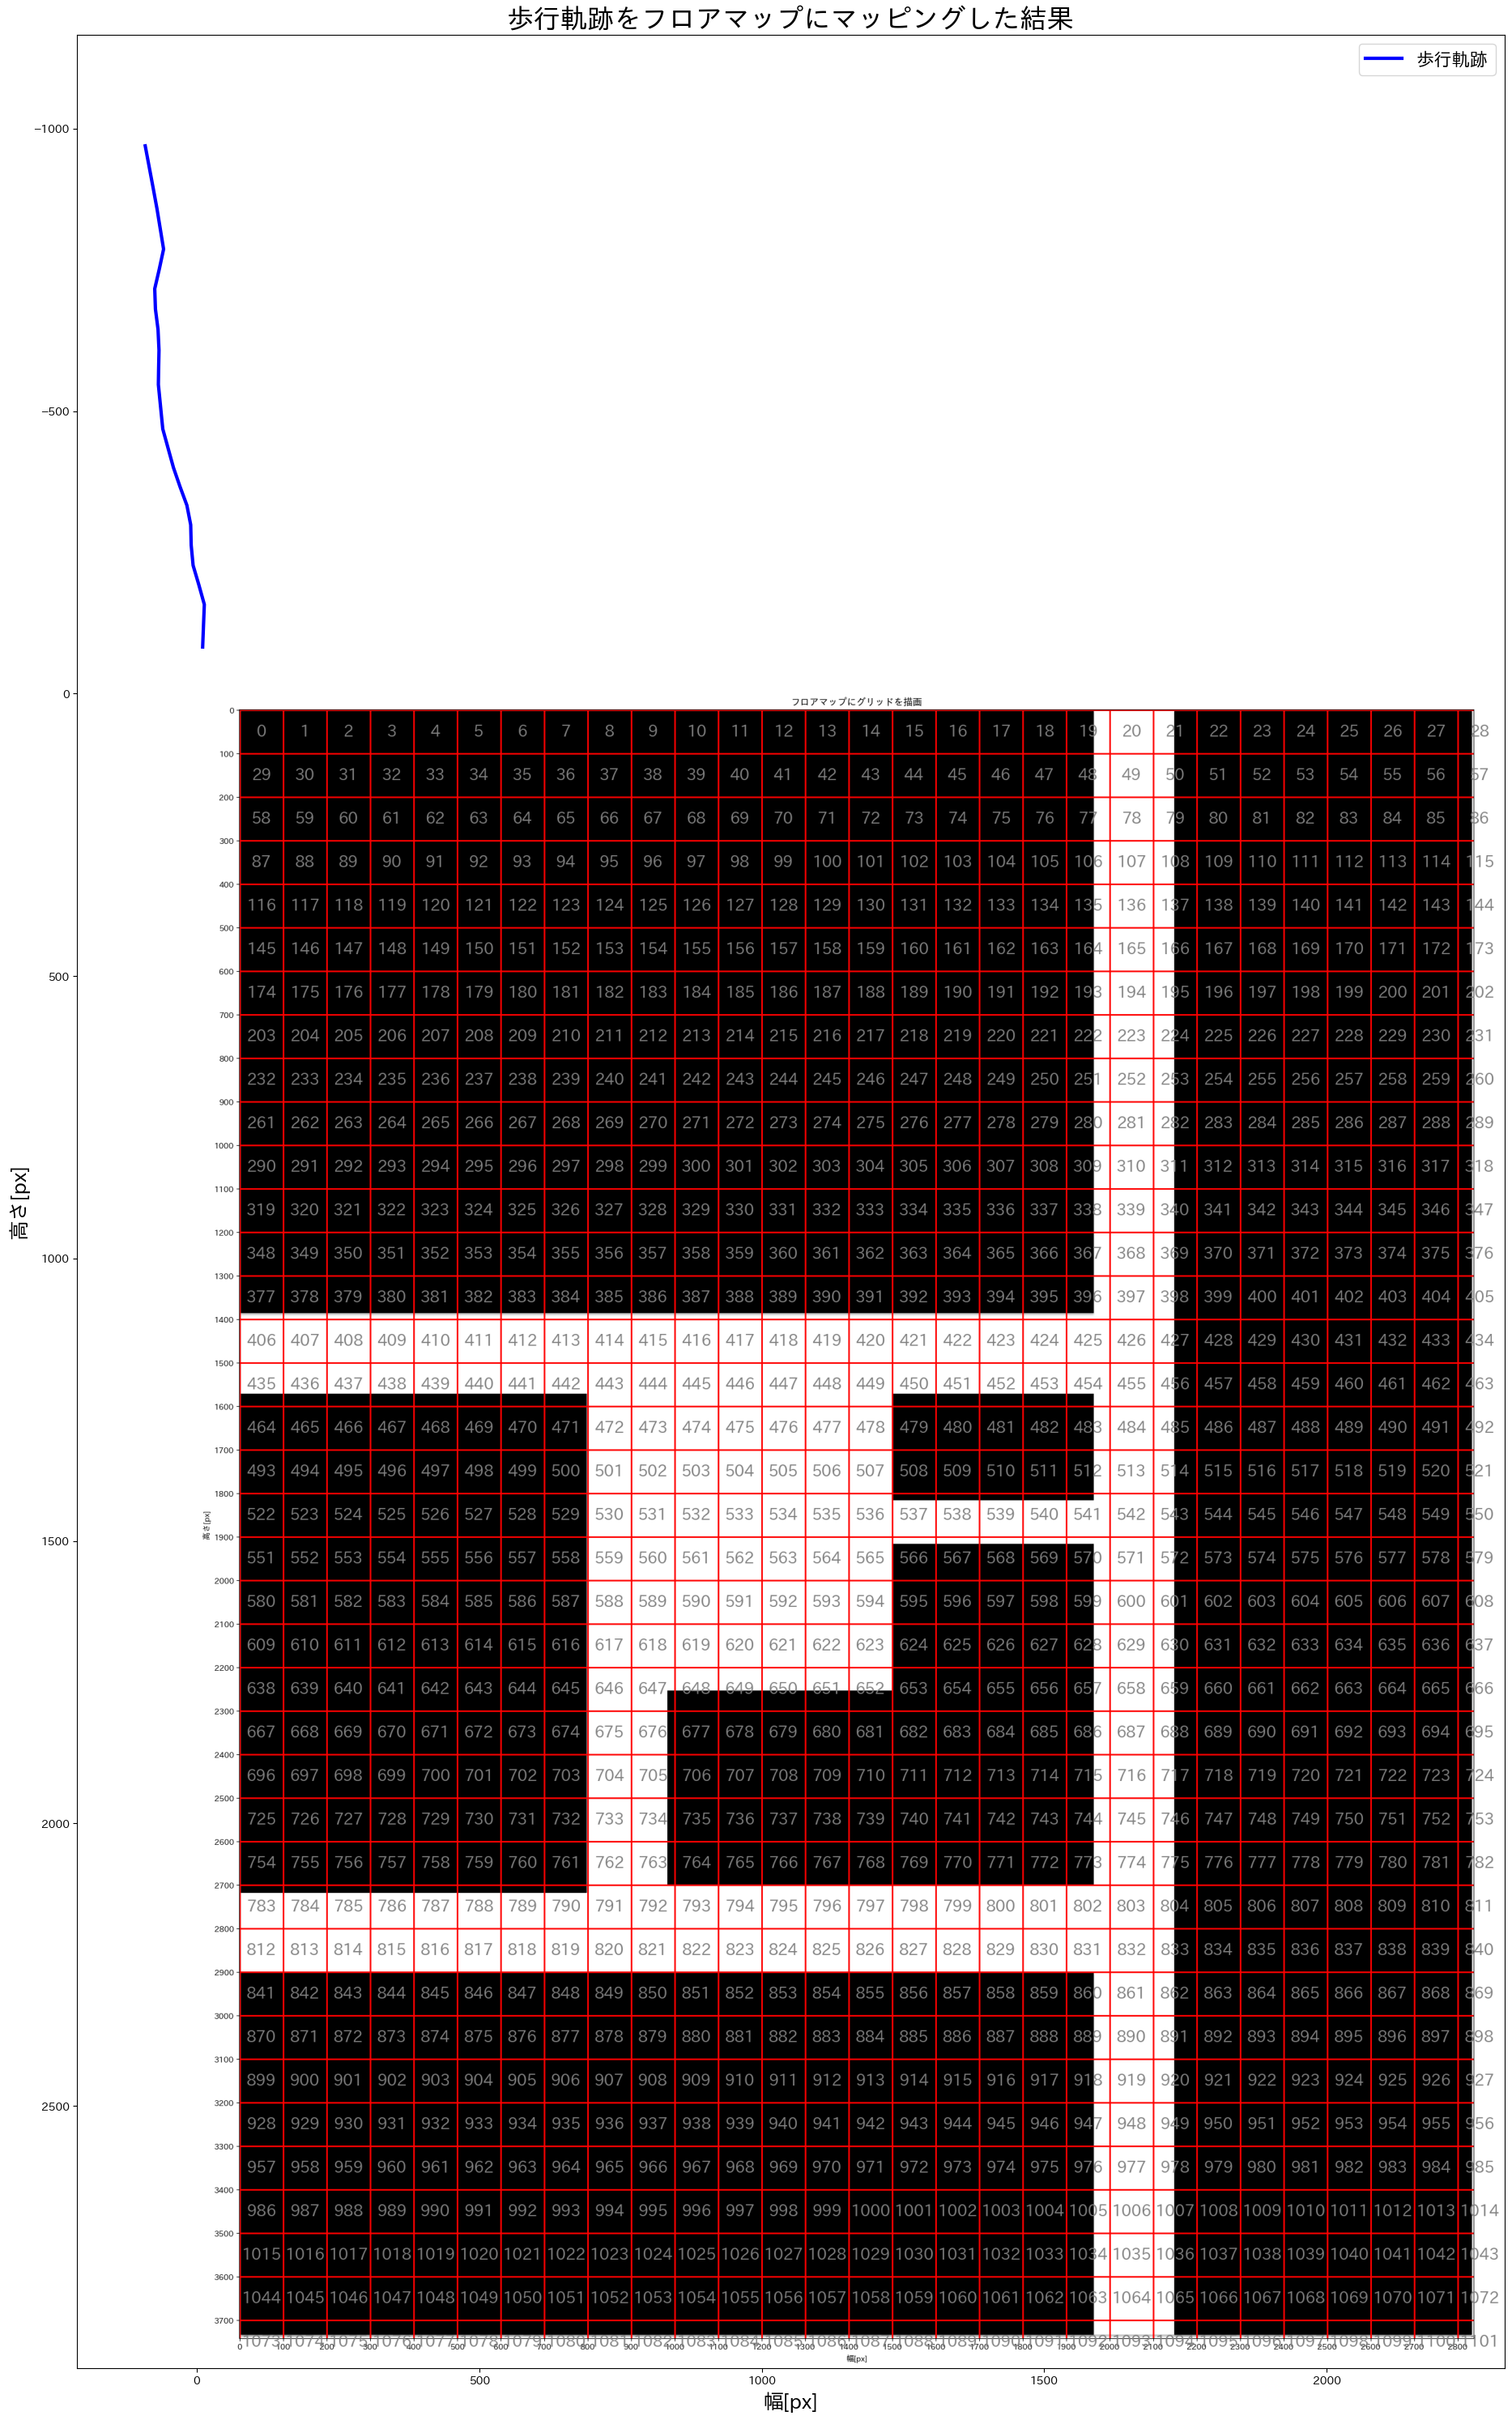

In [118]:
# グリッド付きフロアマップ画像を読み込み
img_grid = Image.open("output/gridFloorMap.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img_grid)

# 変換後の軌跡をプロット
ax.plot(df_trajectory['x'], df_trajectory['y'], 
        color='blue', linewidth=3, label='歩行軌跡')

# グラフの装飾
plt.title('歩行軌跡をフロアマップにマッピングした結果', fontsize=24)
plt.xlabel('幅[px]', fontsize=18)
plt.ylabel('高さ[px]', fontsize=18)
plt.legend(fontsize=16)
plt.show()


In [119]:
# 3. 平行移動量（オフセット）を計算
initial_position = 652

start_grid_info = next(item for item in grid_data if item["id"] == initial_position)
offset_x = start_grid_info['x_min'] + grid_size / 2
offset_y = start_grid_info['y_min'] + grid_size / 2

# 3. 平行移動を適用
x_global_px = x_rotated_px + offset_x
y_global_px = y_rotated_px + offset_y

# 回転後の座標を持つ新しいデータフレームを作成
df_trajectory = pd.DataFrame({
    'x': x_global_px,
    'y': y_global_px
 })


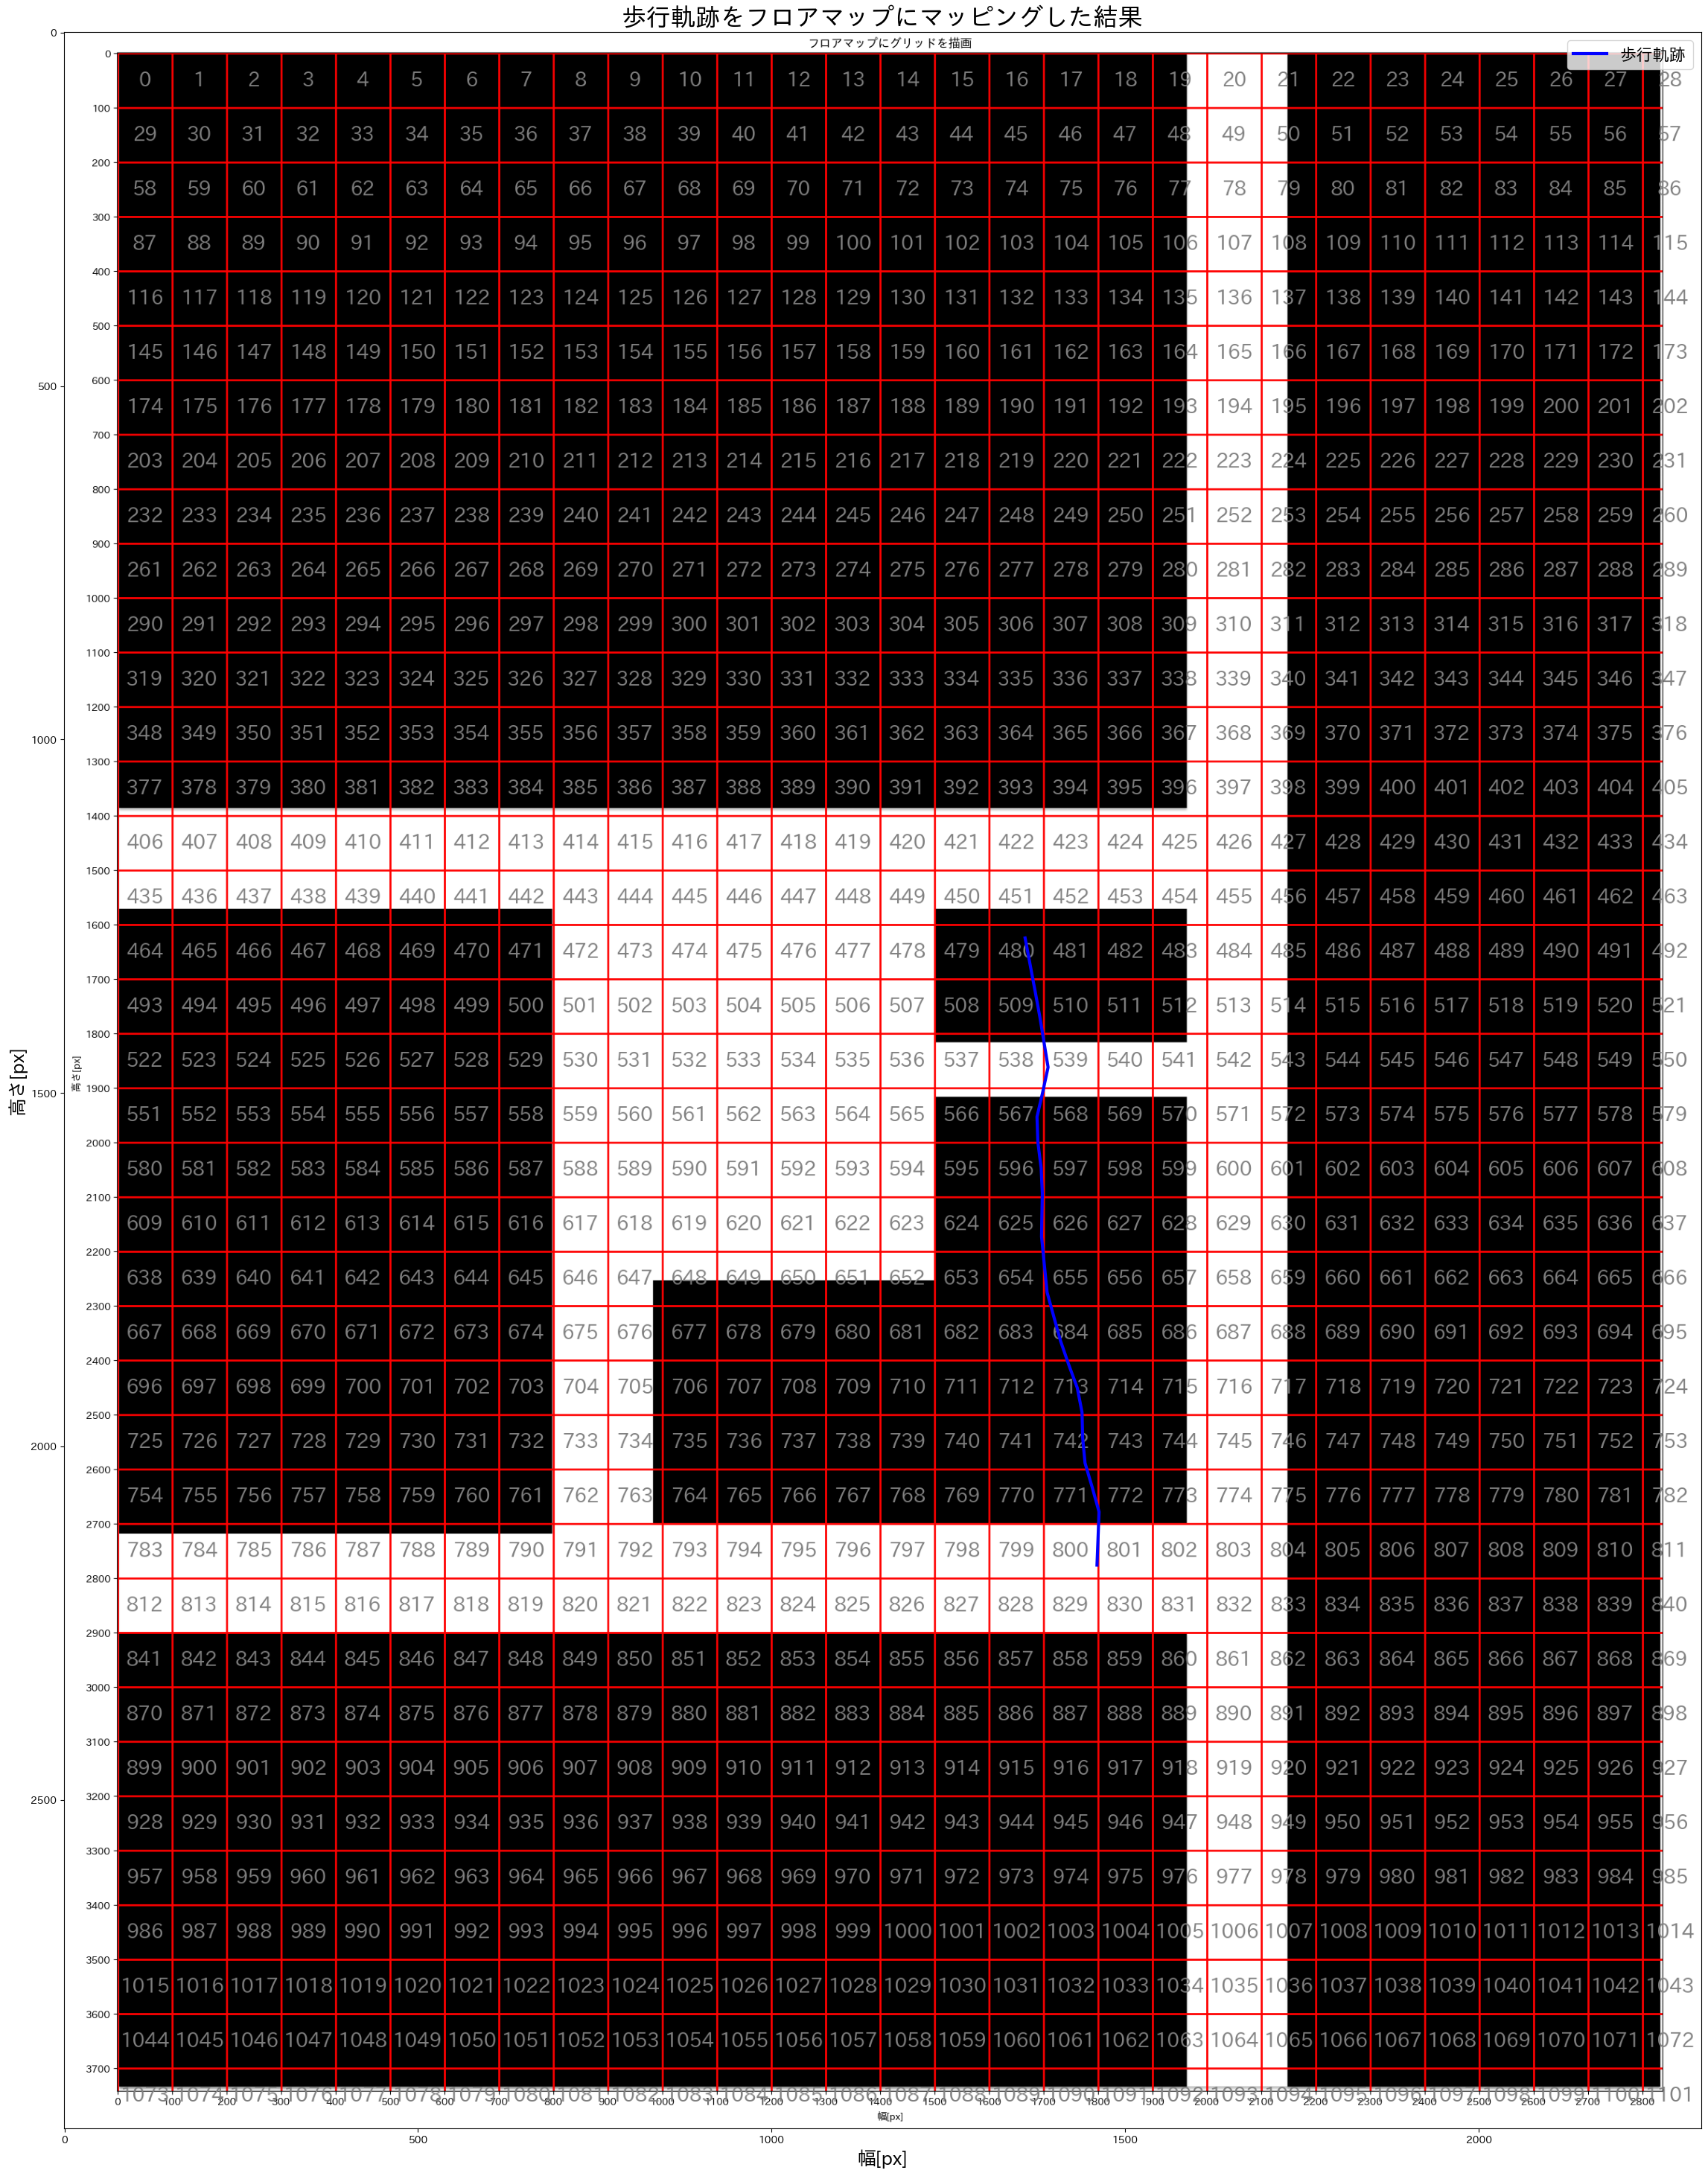

In [120]:
# グリッド付きフロアマップ画像を読み込み
img_grid = Image.open("output/gridFloorMap.png")

# プロットの設定
fig, ax = plt.subplots(figsize=(map_width/100, map_height/100), dpi=100)
ax.imshow(img_grid)

# 変換後の軌跡をプロット
ax.plot(df_trajectory['x'], df_trajectory['y'], 
        color='blue', linewidth=3, label='歩行軌跡')

# グラフの装飾
plt.title('歩行軌跡をフロアマップにマッピングした結果', fontsize=24)
plt.xlabel('幅[px]', fontsize=18)
plt.ylabel('高さ[px]', fontsize=18)
plt.legend(fontsize=16)
plt.show()
